In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [3]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('BK','HL'), 
         ('BK','SPXC'), 
         ('BK','DY'), 
         ('CMI','HL'), 
         ('CMI', 'SPXC'),
         ('CMI', 'DY'), 
         ('GLW','HL'), 
         ('GLW', 'SPXC'), 
         ('GLW','DY')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [4]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.1s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

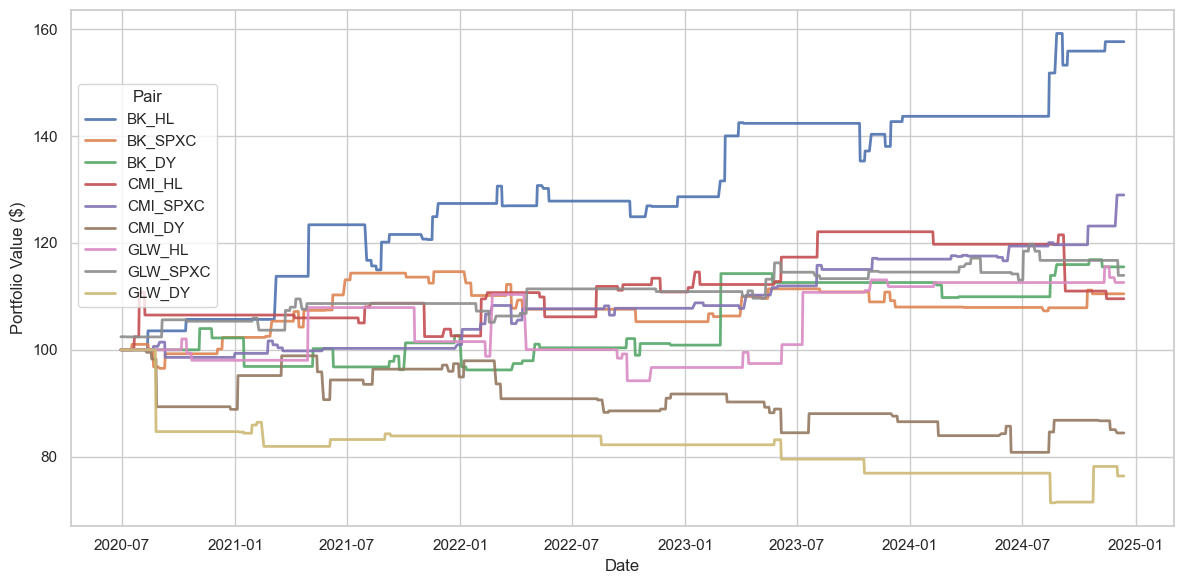

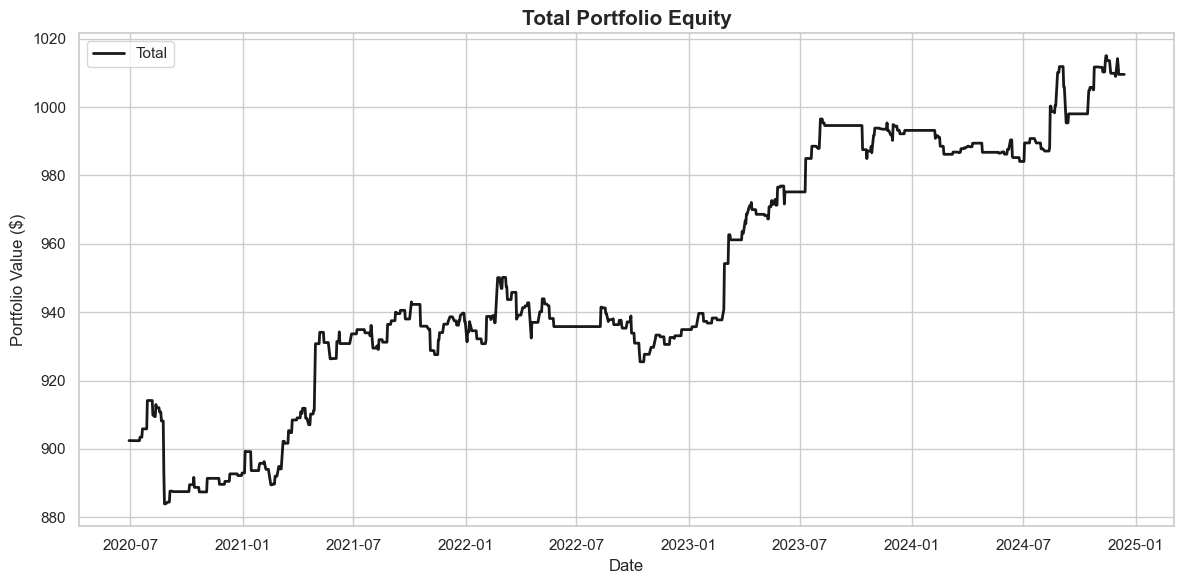

Summary
BK_HL: Final Value = $157.70, Total Return = 57.70%, Trades = 38
BK_SPXC: Final Value = $110.48, Total Return = 10.48%, Trades = 42
BK_DY: Final Value = $115.52, Total Return = 15.52%, Trades = 29
CMI_HL: Final Value = $109.56, Total Return = 9.56%, Trades = 29
CMI_SPXC: Final Value = $128.99, Total Return = 28.99%, Trades = 42
CMI_DY: Final Value = $84.42, Total Return = -15.58%, Trades = 42
GLW_HL: Final Value = $112.60, Total Return = 12.60%, Trades = 23
GLW_SPXC: Final Value = $113.92, Total Return = 11.21%, Trades = 38
GLW_DY: Final Value = $76.36, Total Return = -23.64%, Trades = 18

Total Portfolio Performance
Initial Portfolio Value: $902.44
Final Portfolio Value:   $1,009.57
Total Return:            11.87%

Sharpe Ratios
BK_HL: Sharpe Ratio = 1.10
BK_SPXC: Sharpe Ratio = 0.42
BK_DY: Sharpe Ratio = 0.40
CMI_HL: Sharpe Ratio = 0.27
CMI_SPXC: Sharpe Ratio = 1.17
CMI_DY: Sharpe Ratio = -0.35
GLW_HL: Sharpe Ratio = 0.29
GLW_SPXC: Sharpe Ratio = 0.47
GLW_DY: Sharpe Ratio = -

In [5]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)